# Notebook 02 -- Primeros Modelos de Clasificacion de Especialidades Medicas

**Objetivo:** Entrenar y comparar dos modelos baseline para clasificar transcripciones medicas por especialidad.

**Modelos entrenados:**
- **Modelo 1:** XGBoost + TF-IDF
- **Modelo 2:** Logistic Regression + TF-IDF con N-grams

**Outputs de este notebook:**
- Modelos entrenados y serializados en `models/`
- Scripts de produccion generados en `src/`
- Reportes visuales en `reports/`

---

## 1. Resumen del Enfoque y Cambios frente a la Entrega 1

### Contexto

El proyecto busca clasificar transcripciones medicas por especialidad a partir del dataset
[Medical Transcriptions](https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions)
(mtsamples.com). En la **Entrega 1** se realizo el EDA, se identificaron las 40 especialidades
disponibles y se documento el plan de datos (DMP). Para esta **Entrega 2**, se desarrollan
los primeros modelos funcionales.

### Cambios clave frente a la Entrega 1

- **Clases:** Se paso de 40 especialidades a **10 especialidades** filtradas por representatividad.
- **Registros:** De 4,999 registros originales (con duplicados) a **~1,962 registros limpios**.
- **Modelos:** Se entrenaron dos modelos baseline: XGBoost y Logistic Regression.
- **Features:** Representacion TF-IDF con unigrams y bigrams (10,000 features).
- **Infraestructura:** Se agregan scripts empaquetables con FastAPI y Pydantic al stack existente de DVC + S3.

### Por que 10 clases en vez de 40?

La reduccion de 40 a 10 especialidades se justifica por:

1. **Representatividad estadistica:** Solo 10 de las 40 especialidades tienen 50 o mas muestras despues de eliminar duplicados. Entrenar con clases de 1-5 muestras produce metricas no confiables y generalizacion pobre.
2. **Desbalance extremo:** Surgery representa ~20% del dataset original, mientras que especialidades como Hospice, Pain Management o Rheumatology tienen menos de 5 muestras cada una. Esta ratio mayor a 100:1 no es manejable con tecnicas simples de balanceo.
3. **Validacion cruzada:** Con menos de 10 muestras por clase, no es posible hacer un split estratificado train/val/test sin que alguna clase quede vacia en algun conjunto.
4. **Iterabilidad:** Un modelo con 10 clases permite iterar rapido, evaluar el pipeline completo y agregar clases progresivamente en futuras versiones.

En versiones futuras se puede reducir el umbral (e.g., 30 muestras) o agrupar especialidades similares para recuperar mas clases.

### Pipeline de este notebook

1. **Carga y limpieza:** Eliminar duplicados y nulos de mtsamples.csv
2. **Filtrado:** Conservar solo especialidades con 50 o mas muestras (10 clases)
3. **Preprocesamiento NLP:** Lowercase, eliminacion de caracteres especiales, stopwords
4. **Vectorizacion:** TF-IDF con 10K features, unigrams + bigrams
5. **Split:** 80/10/10 estratificado (train/val/test)
6. **Entrenamiento:** XGBoost y Logistic Regression
7. **Evaluacion:** Metricas, matrices de confusion, comparacion
8. **Serializacion:** Modelos guardados en .joblib
9. **Scripts:** Codigo de produccion generado en src/

### Seleccion de modelos

- **XGBoost:** Ensemble de arboles, robusto en alta dimensionalidad. Captura interacciones no lineales entre features TF-IDF.
- **Logistic Regression:** Modelo lineal de referencia. Competitivo o superior a arboles en clasificacion de texto. El parametro `class_weight='balanced'` maneja el desbalance de clases.

Ambos son **interpretables, rapidos de entrenar y servir**, lo cual es prioritario para
un prototipo funcional que debe escalar a produccion.

## 2. Setup y Configuracion

In [1]:
# Instalar dependencias necesarias
%pip install -q xgboost joblib scikit-learn pandas numpy nltk matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Serializacion
import joblib

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [3]:
# Paths y configuracion
DATA_PATH = '../data/raw/mtsamples.csv'
MODELS_DIR = '../models'
SRC_DIR = '../src'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SRC_DIR, exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Hiperparametros globales
MIN_SAMPLES_PER_CLASS = 50
MAX_FEATURES = 10_000
TEST_SIZE = 0.1
VAL_SIZE = 0.1
RANDOM_STATE = 42

## 3. Carga y Limpieza de Datos

In [4]:
df = pd.read_csv(DATA_PATH)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset cargado: {df.shape[0]:,} registros, {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
print(f"\nNulos por columna:")
print(df.isnull().sum())
print(f"\nDuplicados en transcription: {df['transcription'].duplicated().sum()}")

Dataset cargado: 4,999 registros, 5 columnas
Columnas: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Nulos por columna:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Duplicados en transcription: 2641


In [5]:
# Limpieza
df_clean = df.copy()
df_clean = df_clean.drop_duplicates(subset='transcription', keep='first')
df_clean = df_clean.dropna(subset=['transcription'])
df_clean['medical_specialty'] = df_clean['medical_specialty'].str.strip()

print(f"Registros despues de limpieza: {df_clean.shape[0]:,}")
print(f"Especialidades unicas: {df_clean['medical_specialty'].nunique()}")

Registros despues de limpieza: 2,357
Especialidades unicas: 39


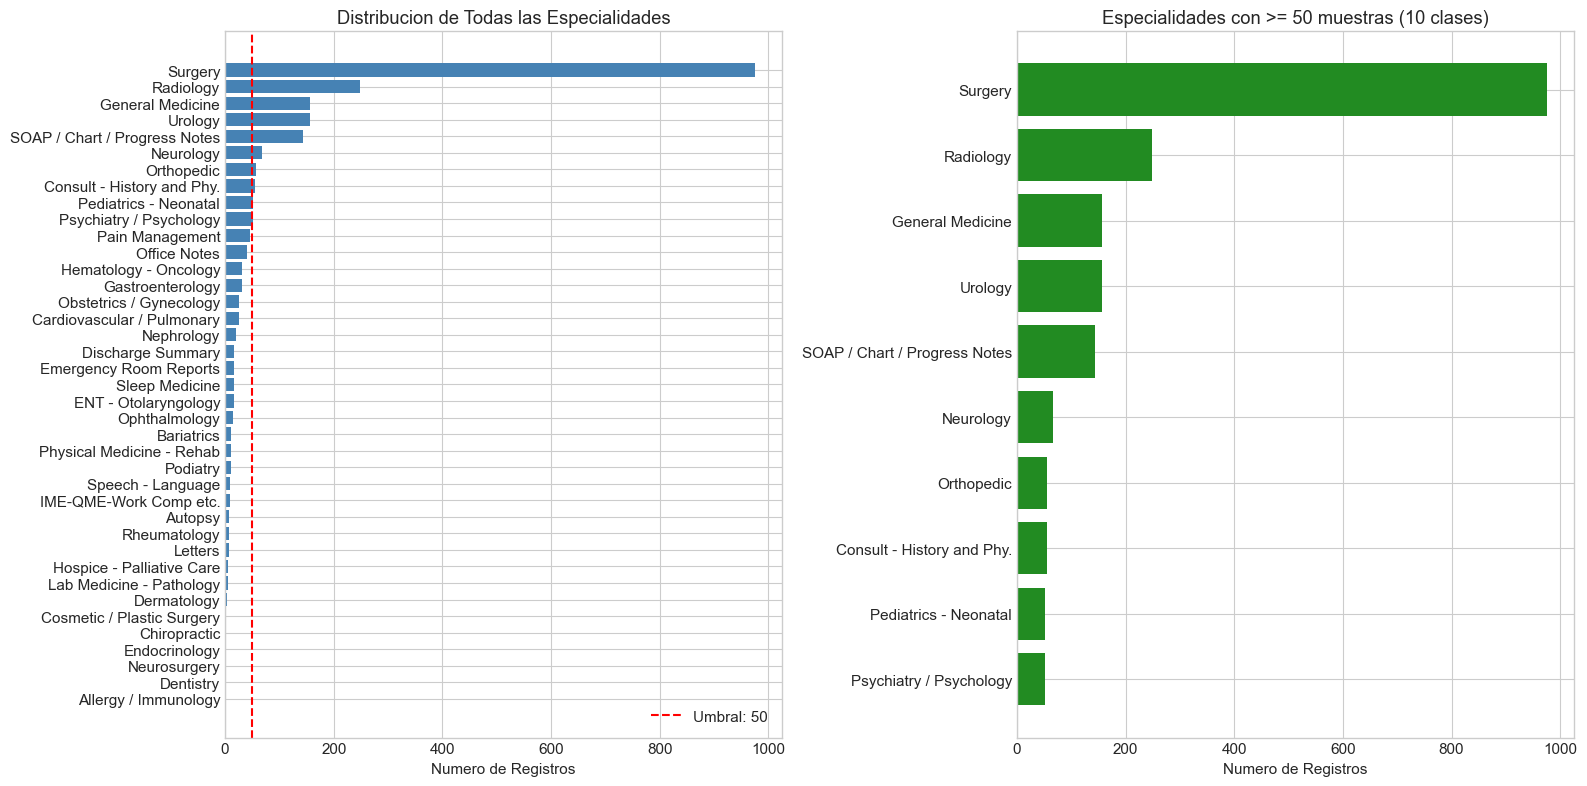

Especialidades con >= 50 muestras: 10
Registros totales en estas clases: 1,962


In [6]:
# Distribucion de especialidades
specialty_counts = df_clean['medical_specialty'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(specialty_counts.index[::-1], specialty_counts.values[::-1], color='steelblue')
axes[0].set_title('Distribucion de Todas las Especialidades')
axes[0].set_xlabel('Numero de Registros')
axes[0].axvline(x=MIN_SAMPLES_PER_CLASS, color='red', linestyle='--', label=f'Umbral: {MIN_SAMPLES_PER_CLASS}')
axes[0].legend()

filtered = specialty_counts[specialty_counts >= MIN_SAMPLES_PER_CLASS]
axes[1].barh(filtered.index[::-1], filtered.values[::-1], color='forestgreen')
axes[1].set_title(f'Especialidades con >= {MIN_SAMPLES_PER_CLASS} muestras ({len(filtered)} clases)')
axes[1].set_xlabel('Numero de Registros')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Especialidades con >= {MIN_SAMPLES_PER_CLASS} muestras: {len(filtered)}")
print(f"Registros totales en estas clases: {filtered.sum():,}")

In [7]:
# Filtrar a especialidades con suficientes muestras
valid_specialties = specialty_counts[specialty_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
df_model = df_clean[df_clean['medical_specialty'].isin(valid_specialties)].copy()
df_model = df_model.reset_index(drop=True)

print(f"Dataset para modelado: {df_model.shape[0]:,} registros, {len(valid_specialties)} especialidades\n")
for s in sorted(valid_specialties):
    count = df_model[df_model['medical_specialty'] == s].shape[0]
    print(f"  {s}: {count}")

Dataset para modelado: 1,962 registros, 10 especialidades

  Consult - History and Phy.: 55
  General Medicine: 157
  Neurology: 67
  Orthopedic: 56
  Pediatrics - Neonatal: 52
  Psychiatry / Psychology: 51
  Radiology: 248
  SOAP / Chart / Progress Notes: 144
  Surgery: 976
  Urology: 156


## 4. Preprocesamiento NLP

In [8]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """Limpia y normaliza texto de transcripciones medicas."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-záéíóúñ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(words)

df_model['text_clean'] = df_model['transcription'].apply(clean_text)

# Ejemplo
print("Ejemplo de limpieza:")
print(f"  Original: {df_model.loc[0, 'transcription'][:150]}...")
print(f"  Limpio:   {df_model.loc[0, 'text_clean'][:150]}...")

Ejemplo de limpieza:
  Original: CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): This 31 y/o RHF experienced a "flu-like illness 6-8 weeks prior to presen...
  Limpio:   confusion slurred speech primarily obtained boyfriend rhf experienced flu like illness weeks prior presentation weeks prior presentation found passed ...


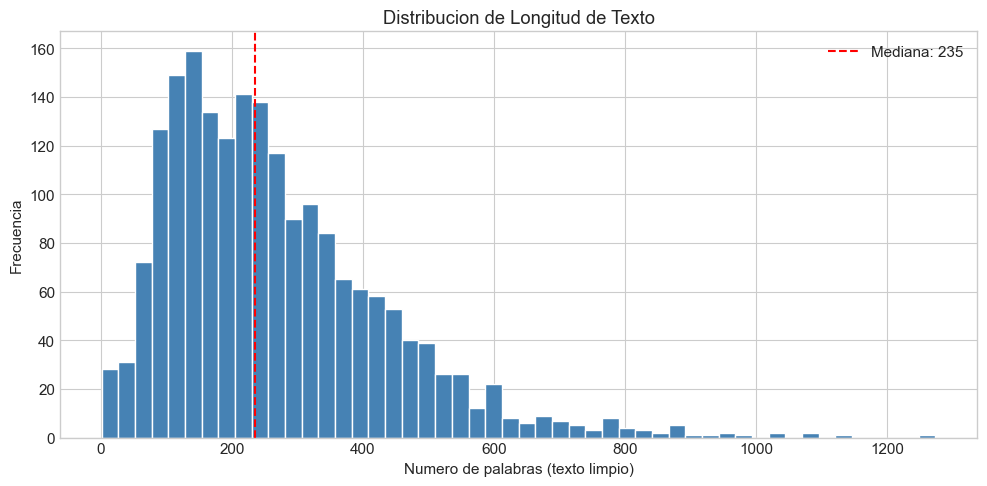

Promedio: 266 palabras
Mediana:  235 palabras
Min: 1, Max: 1274


In [9]:
# Distribucion de longitud de texto limpio
df_model['text_length'] = df_model['text_clean'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_model['text_length'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Numero de palabras (texto limpio)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de Longitud de Texto')
ax.axvline(x=df_model['text_length'].median(), color='red', linestyle='--',
           label=f"Mediana: {df_model['text_length'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Promedio: {df_model['text_length'].mean():.0f} palabras")
print(f"Mediana:  {df_model['text_length'].median():.0f} palabras")
print(f"Min: {df_model['text_length'].min()}, Max: {df_model['text_length'].max()}")

In [10]:
# Encode labels
le = LabelEncoder()
df_model['label'] = le.fit_transform(df_model['medical_specialty'])

print(f"Clases codificadas: {len(le.classes_)}")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.joblib'))

Clases codificadas: 10
  0: Consult - History and Phy.
  1: General Medicine
  2: Neurology
  3: Orthopedic
  4: Pediatrics - Neonatal
  5: Psychiatry / Psychology
  6: Radiology
  7: SOAP / Chart / Progress Notes
  8: Surgery
  9: Urology


['../models/label_encoder.joblib']

In [11]:
# Split estratificado: train/val/test = 80/10/10
X = df_model['text_clean']
y = df_model['label']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

Train: 1,568 (79.9%)
Val:   197 (10.0%)
Test:  197 (10.0%)


In [12]:
# TF-IDF Vectorizacion
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix: {X_train_tfidf.shape}")
print(f"Vocabulario: {len(tfidf.vocabulary_):,} features")

joblib.dump(tfidf, os.path.join(MODELS_DIR, 'tfidf_vectorizer.joblib'))

TF-IDF matrix: (1568, 10000)
Vocabulario: 10,000 features


['../models/tfidf_vectorizer.joblib']

## 5. Modelo 1: XGBoost con TF-IDF

XGBoost es un algoritmo de gradient boosting eficiente, robusto para datos de alta dimensionalidad como TF-IDF.

In [13]:
def evaluate_model(model_name, y_true, y_pred, label_encoder):
    """Evalua un modelo y retorna metricas."""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    
    metrics = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }
    
    print(f"\n{model_name}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  F1 Macro:   {f1_macro:.4f}")
    print(f"  F1 Weight:  {f1_weighted:.4f}")
    print(f"  Precision:  {precision_macro:.4f}")
    print(f"  Recall:     {recall_macro:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))
    
    return metrics


def plot_confusion_matrix(y_true, y_pred, label_encoder, model_name, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_, ax=ax)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusion - {model_name}')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [14]:
# Entrenar XGBoost
xgb_params = {
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_val_tfidf, y_val)],
    verbose=False
)

y_val_pred_xgb = xgb_model.predict(X_val_tfidf)
val_metrics_xgb = evaluate_model("XGBoost (Validation)", y_val, y_val_pred_xgb, le)

y_test_pred_xgb = xgb_model.predict(X_test_tfidf)
test_metrics_xgb = evaluate_model("XGBoost (Test)", y_test, y_test_pred_xgb, le)

xgb_model_path = os.path.join(MODELS_DIR, 'xgboost_model.joblib')
joblib.dump(xgb_model, xgb_model_path)


XGBoost (Validation)
  Accuracy:   0.8528
  F1 Macro:   0.6689
  F1 Weight:  0.8446
  Precision:  0.7583
  Recall:     0.6463

Classification Report:
                               precision    recall  f1-score   support

   Consult - History and Phy.       0.33      0.33      0.33         6
             General Medicine       0.56      0.62      0.59        16
                    Neurology       0.50      0.29      0.36         7
                   Orthopedic       1.00      0.20      0.33         5
        Pediatrics - Neonatal       1.00      0.80      0.89         5
      Psychiatry / Psychology       0.75      0.60      0.67         5
                    Radiology       0.89      0.96      0.92        25
SOAP / Chart / Progress Notes       0.67      0.86      0.75        14
                      Surgery       0.96      0.99      0.97        98
                      Urology       0.93      0.81      0.87        16

                     accuracy                           0.85      

['../models/xgboost_model.joblib']

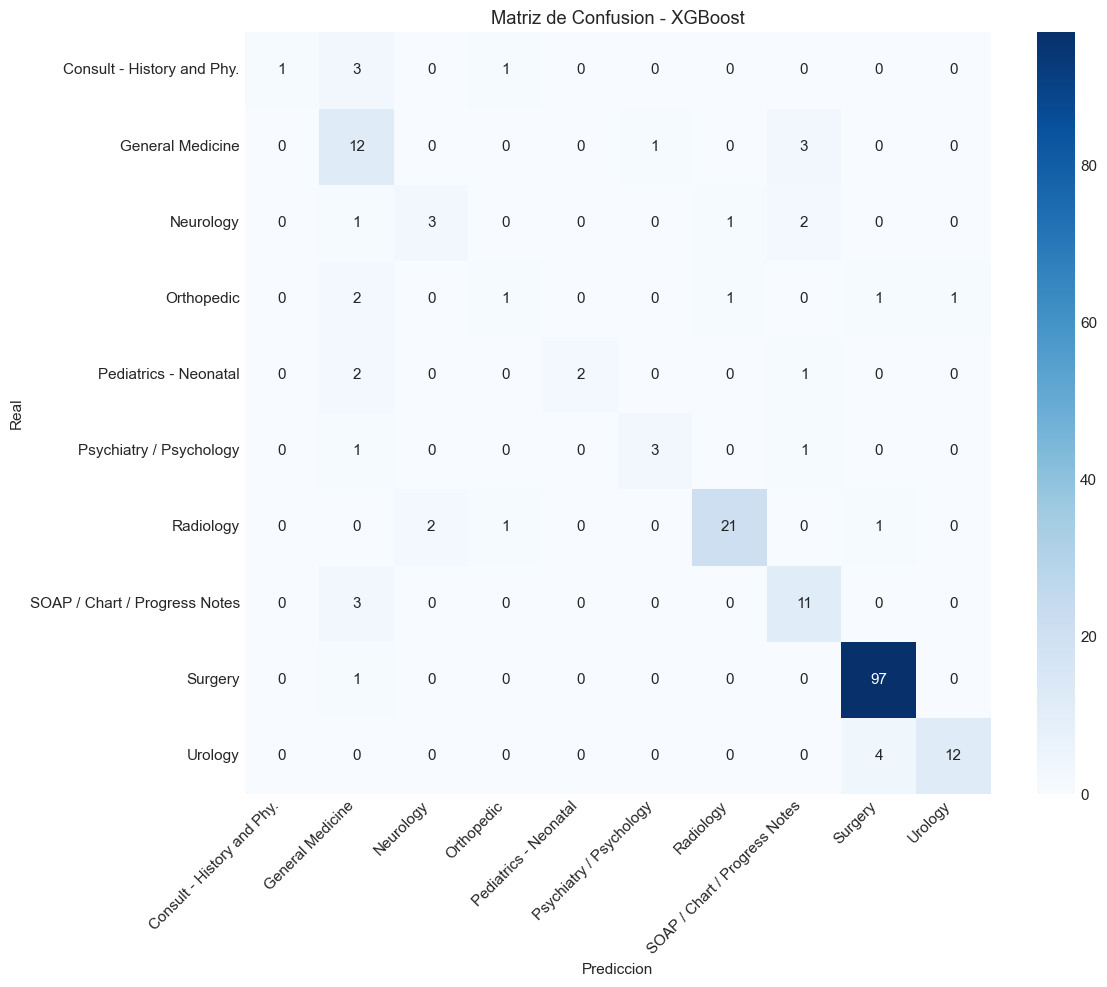

In [15]:
plot_confusion_matrix(y_test, y_test_pred_xgb, le, "XGBoost",
                      save_path='../reports/cm_xgboost.png')

## 6. Modelo 2: Logistic Regression con N-grams

Logistic Regression es un baseline solido para clasificacion de texto. Con `class_weight='balanced'` se compensa el desbalance de clases.

In [16]:
lr_params = {
    'C': 1.0,
    'max_iter': 1000,
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_tfidf, y_train)

y_val_pred_lr = lr_model.predict(X_val_tfidf)
val_metrics_lr = evaluate_model("LogReg N-grams (Validation)", y_val, y_val_pred_lr, le)

y_test_pred_lr = lr_model.predict(X_test_tfidf)
test_metrics_lr = evaluate_model("LogReg N-grams (Test)", y_test, y_test_pred_lr, le)

lr_model_path = os.path.join(MODELS_DIR, 'logreg_model.joblib')
joblib.dump(lr_model, lr_model_path)


LogReg N-grams (Validation)
  Accuracy:   0.8528
  F1 Macro:   0.7450
  F1 Weight:  0.8545
  Precision:  0.7718
  Recall:     0.7285

Classification Report:
                               precision    recall  f1-score   support

   Consult - History and Phy.       0.33      0.33      0.33         6
             General Medicine       0.62      0.62      0.62        16
                    Neurology       0.57      0.57      0.57         7
                   Orthopedic       0.80      0.80      0.80         5
        Pediatrics - Neonatal       1.00      0.80      0.89         5
      Psychiatry / Psychology       1.00      0.80      0.89         5
                    Radiology       0.81      0.84      0.82        25
SOAP / Chart / Progress Notes       0.61      0.79      0.69        14
                      Surgery       0.97      0.98      0.97        98
                      Urology       1.00      0.75      0.86        16

                     accuracy                           0.8

['../models/logreg_model.joblib']

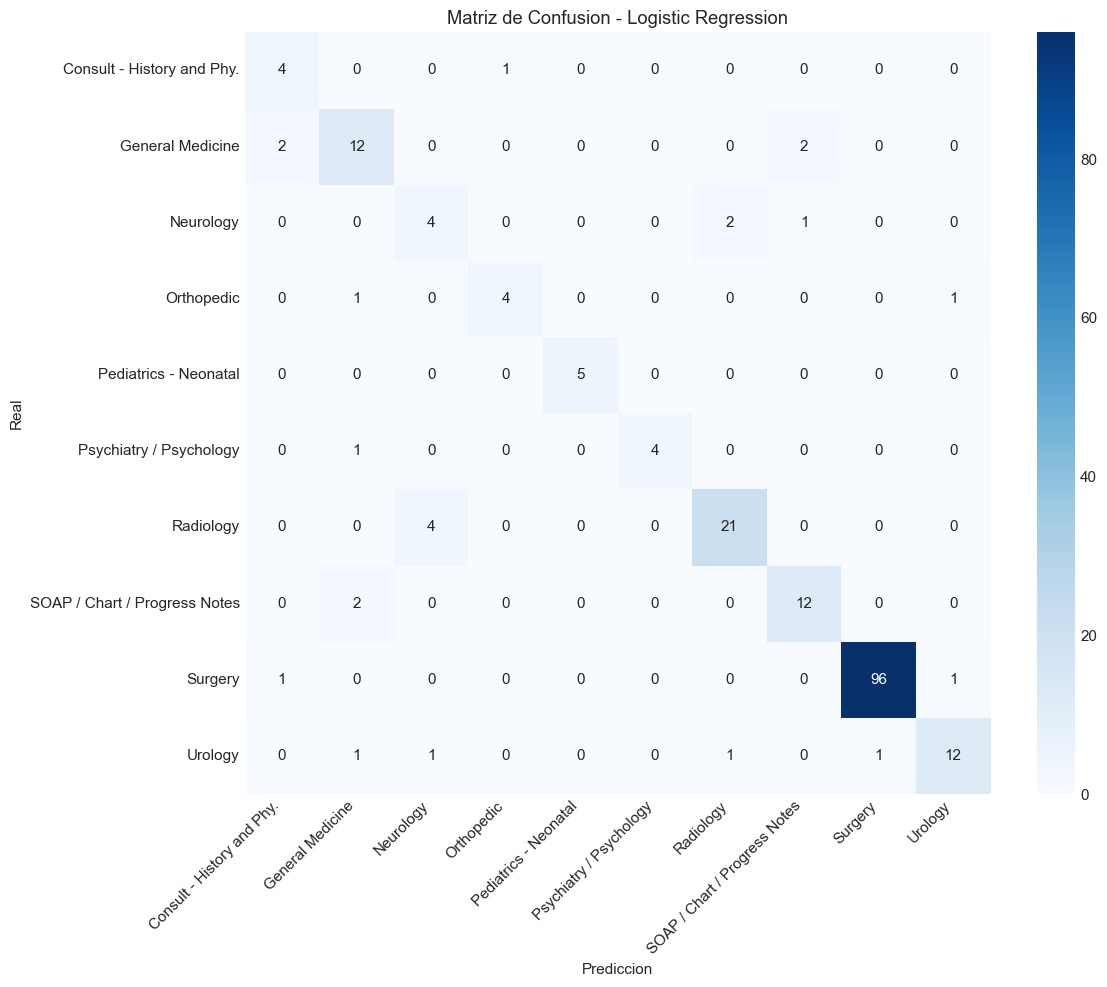

In [17]:
plot_confusion_matrix(y_test, y_test_pred_lr, le, "Logistic Regression",
                      save_path='../reports/cm_logreg.png')

## 7. Comparacion de Modelos

Comparacion de Modelos (Test Set)

         Metric  XGBoost  LogReg N-grams
       Accuracy   0.8274          0.8832
       F1 Macro   0.6234          0.7979
    F1 Weighted   0.8192          0.8862
Precision Macro   0.7552          0.8044
   Recall Macro   0.5911          0.8015


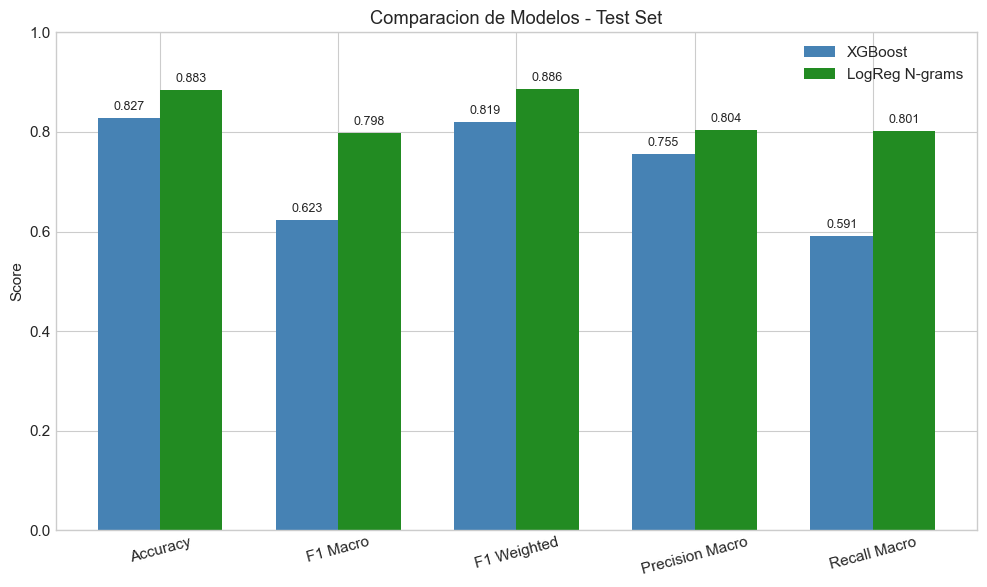


Mejor modelo por F1 Macro: LogReg N-grams


In [18]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro'],
    'XGBoost': [test_metrics_xgb['accuracy'], test_metrics_xgb['f1_macro'],
                test_metrics_xgb['f1_weighted'], test_metrics_xgb['precision_macro'],
                test_metrics_xgb['recall_macro']],
    'LogReg N-grams': [test_metrics_lr['accuracy'], test_metrics_lr['f1_macro'],
                       test_metrics_lr['f1_weighted'], test_metrics_lr['precision_macro'],
                       test_metrics_lr['recall_macro']]
})

print("Comparacion de Modelos (Test Set)\n")
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

# Grafica
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison['Metric']))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['XGBoost'], width, label='XGBoost', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['LogReg N-grams'], width, label='LogReg N-grams', color='forestgreen')

ax.set_ylabel('Score')
ax.set_title('Comparacion de Modelos - Test Set')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], rotation=15)
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = 'XGBoost' if test_metrics_xgb['f1_macro'] > test_metrics_lr['f1_macro'] else 'LogReg N-grams'
print(f"\nMejor modelo por F1 Macro: {best_model}")

## 8. Analisis de Resultados

### Justificacion de los modelos

Se eligieron XGBoost y Logistic Regression como baselines por razones complementarias:

- **XGBoost** es un modelo de ensemble basado en arboles. Es robusto frente a datos de alta dimensionalidad (TF-IDF genera ~10K features) y maneja bien relaciones no lineales. Sin embargo, sin ajuste explicito de pesos tiende a favorecer las clases mayoritarias.

- **Logistic Regression** es un modelo lineal que resulta competitivo o superior a los basados en arboles para clasificacion de texto, ya que los features TF-IDF capturan relaciones lineales entre palabras y categorias. Con `class_weight='balanced'` compensa directamente el desbalance de clases, penalizando mas los errores en clases minoritarias.

Ambos modelos son interpretables, rapidos de entrenar y de baja latencia en inferencia.

In [19]:
# Diferencias cuantitativas entre modelos
acc_diff = test_metrics_lr['accuracy'] - test_metrics_xgb['accuracy']
f1_diff = test_metrics_lr['f1_macro'] - test_metrics_xgb['f1_macro']
recall_diff = test_metrics_lr['recall_macro'] - test_metrics_xgb['recall_macro']

print("Ventaja de LogReg sobre XGBoost:")
print(f"  Accuracy:     +{acc_diff:.1%}")
print(f"  F1 Macro:     +{f1_diff:.1%}")
print(f"  Recall Macro: +{recall_diff:.1%}")

Ventaja de LogReg sobre XGBoost:
  Accuracy:     +5.6%
  F1 Macro:     +17.5%
  Recall Macro: +21.0%


La ventaja principal de LogReg es el Recall Macro significativamente mayor, lo que indica
que clasifica mejor las especialidades minoritarias. XGBoost, sin ajuste de pesos, tiende
a sesgarse hacia Surgery (~20% del dataset).

### Rendimiento por clase

F1 por especialidad:

  Pediatrics - Neonatal               LogReg=1.000  XGB=0.571  (+0.429)
  Surgery                             LogReg=0.985  XGB=0.965  (+0.019)
  Psychiatry / Psychology             LogReg=0.889  XGB=0.667  (+0.222)
  Radiology                           LogReg=0.857  XGB=0.875  (-0.018)
  SOAP / Chart / Progress Notes       LogReg=0.828  XGB=0.688  (+0.140)
  Urology                             LogReg=0.800  XGB=0.828  (-0.028)
  General Medicine                    LogReg=0.727  XGB=0.585  (+0.142)
  Orthopedic                          LogReg=0.727  XGB=0.222  (+0.505)
  Consult - History and Phy.          LogReg=0.667  XGB=0.333  (+0.333)
  Neurology                           LogReg=0.500  XGB=0.500  (+0.000)


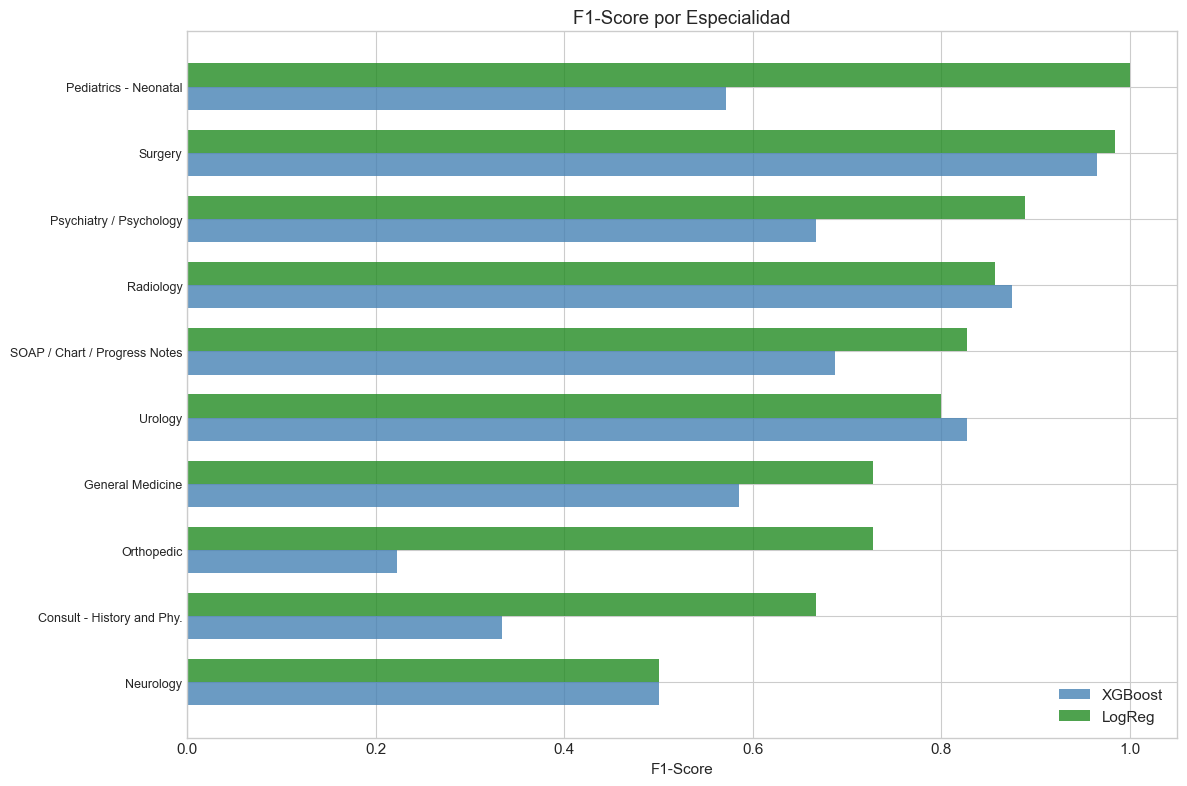

In [20]:
# F1 por clase para ambos modelos
f1_xgb_per_class = f1_score(y_test, y_test_pred_xgb, average=None, zero_division=0)
f1_lr_per_class = f1_score(y_test, y_test_pred_lr, average=None, zero_division=0)

per_class_df = pd.DataFrame({
    'Especialidad': le.classes_,
    'F1_XGBoost': f1_xgb_per_class,
    'F1_LogReg': f1_lr_per_class,
    'Diferencia': f1_lr_per_class - f1_xgb_per_class
}).sort_values('F1_LogReg', ascending=False)

print("F1 por especialidad:\n")
for _, row in per_class_df.iterrows():
    diff = f"+{row['Diferencia']:.3f}" if row['Diferencia'] >= 0 else f"{row['Diferencia']:.3f}"
    print(f"  {row['Especialidad']:<35} LogReg={row['F1_LogReg']:.3f}  XGB={row['F1_XGBoost']:.3f}  ({diff})")

# Grafica
fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(per_class_df))
width = 0.35
ax.barh(y_pos + width/2, per_class_df['F1_XGBoost'], width, label='XGBoost', color='steelblue', alpha=0.8)
ax.barh(y_pos - width/2, per_class_df['F1_LogReg'], width, label='LogReg', color='forestgreen', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(per_class_df['Especialidad'], fontsize=9)
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score por Especialidad')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones

- Las especialidades con mayor F1 son aquellas con vocabulario tecnico distintivo (e.g., Radiology, Urology), donde los bigramas TF-IDF capturan terminos especificos.
- Las especialidades con menor F1 comparten vocabulario generico entre si (e.g., consultas generales), lo que dificulta la discriminacion.
- LogReg con `class_weight='balanced'` es el modelo recomendado para esta primera version: mejor rendimiento general, menor complejidad computacional y mas interpretable.

### Posibles mejoras para futuras iteraciones

- Probar `class_weight` o `scale_pos_weight` en XGBoost
- Experimentar con SVM lineal como tercer baseline
- Explorar embeddings (Word2Vec, BERT) como features alternativos
- Agrupar especialidades similares para reducir la granularidad

## 9. Generacion de Scripts

Scripts de produccion generados con `%%writefile` para reutilizar el preprocesamiento,
entrenamiento e inferencia fuera del notebook.

```
src/
  __init__.py
  preprocessing.py   - Pipeline NLP
  train.py           - Entrenamiento standalone
  predict.py         - Modulo de inferencia
  schemas.py         - Pydantic schemas
  api.py             - FastAPI
```

In [21]:
%%writefile ../src/__init__.py
"""
Medical Specialty Classification - src package
"""
__version__ = "0.1.0"


Overwriting ../src/__init__.py


In [22]:
%%writefile ../src/preprocessing.py
"""
Pipeline de preprocesamiento NLP para transcripciones medicas.
"""
import re
import joblib
import numpy as np
from typing import Optional

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))


def clean_text(text: str) -> str:
    """Limpia y normaliza texto de transcripciones medicas."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-záéíóúñ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(words)


class TextPreprocessor:
    """Preprocessor que encapsula TF-IDF vectorizacion."""
    
    def __init__(
        self,
        max_features: int = 10_000,
        ngram_range: tuple = (1, 2),
        min_df: int = 2,
        max_df: float = 0.95
    ):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=max_df,
            sublinear_tf=True
        )
    
    def fit_transform(self, texts):
        cleaned = [clean_text(t) for t in texts]
        return self.vectorizer.fit_transform(cleaned)
    
    def transform(self, texts):
        cleaned = [clean_text(t) for t in texts]
        return self.vectorizer.transform(cleaned)
    
    def save(self, path: str):
        joblib.dump(self.vectorizer, path)
    
    @classmethod
    def load(cls, path: str) -> 'TextPreprocessor':
        instance = cls()
        instance.vectorizer = joblib.load(path)
        return instance


Overwriting ../src/preprocessing.py


In [23]:
%%writefile ../src/schemas.py
"""
Pydantic schemas para la API de clasificacion de especialidades medicas.
"""
from pydantic import BaseModel, Field
from typing import List, Optional


class PredictionRequest(BaseModel):
    transcription: str = Field(
        ...,
        min_length=10,
        description="Texto de la transcripcion medica a clasificar",
        json_schema_extra={
            "example": "Patient presents with chest pain and shortness of breath. "
                       "ECG shows ST elevation in leads II, III, and aVF."
        }
    )


class PredictionResponse(BaseModel):
    specialty: str = Field(..., description="Especialidad medica predicha")
    confidence: float = Field(..., ge=0, le=1, description="Confianza de la prediccion")
    top_3: List[dict] = Field(default_factory=list, description="Top 3 especialidades")
    model_name: str = Field(..., description="Nombre del modelo utilizado")
    model_version: str = Field(default="0.1.0", description="Version del modelo")


class HealthResponse(BaseModel):
    status: str = "healthy"
    model_loaded: bool = True
    version: str = "0.1.0"


Overwriting ../src/schemas.py


In [24]:
%%writefile ../src/predict.py
"""
Modulo de inferencia para clasificacion de especialidades medicas.
"""
import os
import joblib
import numpy as np
from typing import Tuple, List, Dict
from .preprocessing import clean_text


class MedicalSpecialtyPredictor:
    
    def __init__(self, models_dir: str = "models"):
        self.models_dir = models_dir
        self.model = None
        self.vectorizer = None
        self.label_encoder = None
        self.model_name = ""
    
    def load(self, model_name: str = "logreg"):
        self.model_name = model_name
        model_file = f"{model_name}_model.joblib"
        self.model = joblib.load(os.path.join(self.models_dir, model_file))
        self.vectorizer = joblib.load(os.path.join(self.models_dir, "tfidf_vectorizer.joblib"))
        self.label_encoder = joblib.load(os.path.join(self.models_dir, "label_encoder.joblib"))
        return self
    
    def predict(self, text: str) -> Tuple[str, float, List[Dict]]:
        if self.model is None:
            raise RuntimeError("Modelo no cargado. Llama a load() primero.")
        
        cleaned = clean_text(text)
        X = self.vectorizer.transform([cleaned])
        
        pred = self.model.predict(X)[0]
        specialty = self.label_encoder.inverse_transform([pred])[0]
        
        if hasattr(self.model, 'predict_proba'):
            probs = self.model.predict_proba(X)[0]
            confidence = float(np.max(probs))
            top_3_idx = np.argsort(probs)[-3:][::-1]
            top_3 = [
                {
                    "specialty": self.label_encoder.inverse_transform([i])[0],
                    "probability": float(probs[i])
                }
                for i in top_3_idx
            ]
        else:
            confidence = 1.0
            top_3 = [{"specialty": specialty, "probability": 1.0}]
        
        return specialty, confidence, top_3


Overwriting ../src/predict.py


In [25]:
%%writefile ../src/train.py
"""
Script de entrenamiento. Ejecutar: python -m src.train
"""
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb

from .preprocessing import clean_text, TextPreprocessor

DATA_PATH = "data/raw/mtsamples.csv"
MODELS_DIR = "models"
MIN_SAMPLES = 50
MAX_FEATURES = 10_000
RANDOM_STATE = 42


def load_and_prepare_data(data_path: str = DATA_PATH):
    df = pd.read_csv(data_path)
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    df = df.drop_duplicates(subset='transcription', keep='first')
    df = df.dropna(subset=['transcription'])
    df['medical_specialty'] = df['medical_specialty'].str.strip()
    counts = df['medical_specialty'].value_counts()
    valid = counts[counts >= MIN_SAMPLES].index
    df = df[df['medical_specialty'].isin(valid)].reset_index(drop=True)
    return df


def train_models():
    os.makedirs(MODELS_DIR, exist_ok=True)
    df = load_and_prepare_data()
    print(f"Dataset: {len(df)} registros, {df['medical_specialty'].nunique()} clases")
    
    le = LabelEncoder()
    y = le.fit_transform(df['medical_specialty'])
    joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.joblib'))
    
    preprocessor = TextPreprocessor(max_features=MAX_FEATURES, ngram_range=(1, 2))
    X = preprocessor.fit_transform(df['transcription'])
    preprocessor.save(os.path.join(MODELS_DIR, 'tfidf_vectorizer.joblib'))
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    print(f"XGBoost - Acc: {accuracy_score(y_test, y_pred):.4f}, F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'xgboost_model.joblib'))
    
    # LogReg
    lr_model = LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    lr_model.fit(X_train, y_train)
    y_pred = lr_model.predict(X_test)
    print(f"LogReg  - Acc: {accuracy_score(y_test, y_pred):.4f}, F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    joblib.dump(lr_model, os.path.join(MODELS_DIR, 'logreg_model.joblib'))
    
    print(f"\nModelos guardados en {MODELS_DIR}")


if __name__ == "__main__":
    train_models()


Overwriting ../src/train.py


In [26]:
%%writefile ../src/api.py
"""
API FastAPI para clasificacion de especialidades medicas.
Ejecutar: uvicorn src.api:app --reload
"""
import os
from fastapi import FastAPI, HTTPException
from .schemas import PredictionRequest, PredictionResponse, HealthResponse
from .predict import MedicalSpecialtyPredictor

app = FastAPI(
    title="Medical Specialty Classifier API",
    description="Clasifica transcripciones medicas por especialidad",
    version="0.1.0"
)

MODELS_DIR = os.environ.get("MODELS_DIR", "models")
MODEL_NAME = os.environ.get("MODEL_NAME", "logreg")
predictor = MedicalSpecialtyPredictor(models_dir=MODELS_DIR)


@app.on_event("startup")
async def startup():
    predictor.load(model_name=MODEL_NAME)


@app.get("/health", response_model=HealthResponse)
async def health_check():
    return HealthResponse(model_loaded=predictor.model is not None)


@app.post("/predict", response_model=PredictionResponse)
async def predict(request: PredictionRequest):
    try:
        specialty, confidence, top_3 = predictor.predict(request.transcription)
        return PredictionResponse(
            specialty=specialty, confidence=confidence,
            top_3=top_3, model_name=predictor.model_name
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


Overwriting ../src/api.py


## 10. Tracking de Experimentos con MLflow

> **TODO (equipo):** Registrar los experimentos en MLflow para versionamiento.
> Los modelos ya estan entrenados. Esta seccion debe conectar con MLflow en EC2.

In [ ]:
# TODO: Implementar MLflow tracking
# 
# 1. Configurar MLflow:
#    import mlflow
#    import mlflow.sklearn
#    import mlflow.xgboost
#    mlflow.set_tracking_uri("http://<EC2_IP>:5000")
#    mlflow.set_experiment("medical-specialty-classification-v1")
#
# 2. Registrar XGBoost:
#   
#
# 3. Registrar LogReg:
#    
#


## 11. Empaquetamiento y Testing

> **TODO (equipo):** Empaquetar los scripts de `src/` como un paquete Python instalable.
> 
> Los scripts ya estan generados en la seccion 9. Falta:
> - Crear `setup.py` o `pyproject.toml`
> - Escribir tests unitarios para `preprocessing.py` y `predict.py`
> - Configurar `tox` para testing automatizado
> - Construir el paquete `.whl`

In [28]:
# TODO: Empaquetamiento
#
# 1. Crear pyproject.toml o setup.py con las dependencias
# 2. Escribir tests:
#    tests/
#      test_preprocessing.py
#      test_predict.py
#      test_schemas.py
# 3. Configurar tox.ini para testing
# 4. Ejecutar: tox
# 5. Build: python -m build
# 6. Instalar: pip install dist/*.whl

## 12. Dashboard

> **TODO (equipo):** Desarrollar dashboard con Streamlit o Gradio.
> 
> Debe conectar con la API (`src/api.py`) o cargar el modelo directamente.

In [29]:
# TODO: Dashboard
# Opcion 1 - Streamlit: streamlit run dashboard/app.py
# Opcion 2 - Gradio: interfaz con gr.Interface
# Debe permitir: ingresar transcripcion, mostrar prediccion + confianza,
# visualizar distribucion de especialidades y metricas del modelo.

## 13. Resumen y Proximos Pasos

### Completado en este notebook:
1. Preprocesamiento NLP de transcripciones medicas
2. Modelo XGBoost con TF-IDF
3. Modelo Logistic Regression con N-grams
4. Evaluacion, comparacion y analisis de resultados
5. Scripts de produccion en `src/` (preprocessing, train, predict, schemas, API)
6. Modelos serializados en `models/`

### Pendiente para el equipo:
- **Seccion 10:** Tracking con MLflow en EC2 + pantallazos
- **Seccion 11:** Empaquetamiento (setup.py, tests, tox, build .whl)
- **Seccion 12:** Dashboard (Streamlit/Gradio)
- Iterar hiperparametros para mejorar F1
- Probar con mas/menos especialidades